Audit des données brutes

In [1]:
from google.colab import files
uploaded = files.upload()


Saving 2018_Fixed_Leakages_Report.txt to 2018_Fixed_Leakages_Report.txt
Saving 2018_Leakages.csv to 2018_Leakages.csv
Saving 2018_SCADA.xlsx to 2018_SCADA.xlsx
Saving powerconsumption.csv to powerconsumption.csv


In [2]:
import pandas as pd

# Electricité
elec = pd.read_csv("powerconsumption.csv")
print(elec.shape)
print(elec.head())
print(elec.info())

# Eau - SCADA
water = pd.read_excel("2018_SCADA.xlsx")
print(water.shape)
print(water.head())

# Eau - rapport de fuites (texte, fin uniquement)
with open("2018_Fixed_Leakages_Report.txt") as f:
    print(f.read()[:1000])

# Eau - fuites détaillées (CSV, début + fin)
leaks = pd.read_csv("2018_Leakages.csv", sep=";", low_memory=False)
print(leaks.iloc[:, 1:].sum())


(52416, 9)
        Datetime  Temperature  Humidity  WindSpeed  GeneralDiffuseFlows  \
0  1/1/2017 0:00        6.559      73.8      0.083                0.051   
1  1/1/2017 0:10        6.414      74.5      0.083                0.070   
2  1/1/2017 0:20        6.313      74.5      0.080                0.062   
3  1/1/2017 0:30        6.121      75.0      0.083                0.091   
4  1/1/2017 0:40        5.921      75.7      0.081                0.048   

   DiffuseFlows  PowerConsumption_Zone1  PowerConsumption_Zone2  \
0         0.119             34055.69620             16128.87538   
1         0.085             29814.68354             19375.07599   
2         0.100             29128.10127             19006.68693   
3         0.096             28228.86076             18361.09422   
4         0.085             27335.69620             17872.34043   

   PowerConsumption_Zone3  
0             20240.96386  
1             20131.08434  
2             19668.43373  
3             18899.277

Résumé :
Électricité : 52 416 lignes, propre, aucune valeur manquante, 3 zones de consommation + variables météo (température, humidité, vent, flux diffus).
Eau (SCADA) : 105 120 lignes, 34 colonnes de capteurs de pression (n1, n4, n31...) à différents nœuds du réseau — pas de débit visible dans les colonnes affichées, à vérifier plus loin si présent.
Fuites : deux fichiers complémentaires —

2018_Fixed_Leakages_Report.txt : liste simple de 10 fuites réparées avec linkID + date de fin uniquement

2018_Leakages.csv : fichier détaillé et bien plus riche — label binaire (0/1) par pas de 5 minutes pour 14 conduites, permettant de connaître précisément début, fin et durée de chaque fuite. 8 conduites ont eu au moins un épisode de fuite en 2018, 5 n'en ont eu aucune.

EDA — Électricité : tendances temporelles

<Axes: xlabel='Datetime'>

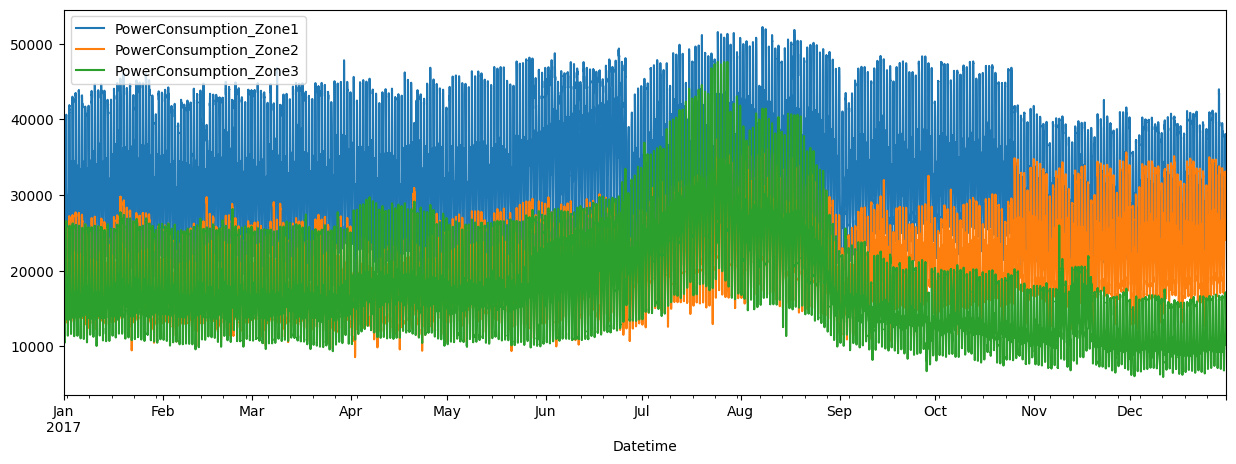

In [3]:
import matplotlib.pyplot as plt
elec['Datetime'] = pd.to_datetime(elec['Datetime'])
elec.set_index('Datetime')[['PowerConsumption_Zone1','PowerConsumption_Zone2','PowerConsumption_Zone3']].plot(figsize=(15,5))